In [108]:
import os
import concurrent.futures
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path
from functools import partial
import shutil

import ee
import xarray as xr
import rioxarray as rio
from tqdm import tqdm
from rasterio.warp import transform, transform_bounds
from pyproj import Transformer

import re
import pandas as pd
import numpy as np
from scipy.ndimage import zoom
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error


ee.Authenticate()
ee.Initialize(
    project='wildfirerisk-476810',
    opt_url="https://earthengine-highvolume.googleapis.com",
)
ee.data.setWorkloadTag('wildfirerisk-476810')
collection = ee.ImageCollection("GOOGLE/SATELLITE_EMBEDDING/V1/ANNUAL")

start = ee.Date.fromYMD(2021, 1, 1)
end = start.advance(1, "year")
collection = collection.filter(ee.Filter.date(start, end))


def resize(img, out_size=341, order=1):
    arr = np.asarray(img)

    if arr.shape[0] == out_size and arr.shape[1] == out_size:
        return arr.copy()

    zoom_h = out_size / arr.shape[0]
    zoom_w = out_size / arr.shape[1]

    zoom_factors = (zoom_h, zoom_w)

    return zoom(arr, zoom_factors, order=order)

def quantize_aef(image):
    """quantize float64 -> uint8"""
    power = 2.0
    scale = 127.5
    min_value = -127
    max_value = 127

    sat = image.abs().pow(ee.Number(1.0).divide(power)).multiply(image.signum())
    snapped = sat.multiply(scale).round()
    return snapped.clamp(min_value, max_value).add(ee.Number(127)).uint8()

def download_tile_embeddings(lat, lon, year=2021, tile_size_m=10230, collection=collection, crs="EPSG:3857"):
    """
    Download the annual embedding tile from GOOGLE/SATELLITE_EMBEDDING/V1/ANNUAL
    centered on (lat, lon) with size tile_size_m x tile_size_m (meters).
    Returns an xarray.Dataset (the Earth Engine-backed dataset).
    Requires Earth Engine to be already authenticated/initialized in the notebook.
    """
    HALF = tile_size_m / 2.0

    # Project the center into the projected CRS (use Albers EPSG:3857 as in this notebook)
    t_ll2ref = Transformer.from_crs("EPSG:4326", crs, always_xy=True)
    cx, cy = t_ll2ref.transform(lon, lat)

    # compute square corners in projected CRS and transform back to lat/lon
    corners_ref = [
        (cx - HALF, cy - HALF),
        (cx + HALF, cy - HALF),
        (cx + HALF, cy + HALF),
        (cx - HALF, cy + HALF),
    ]
    # transformer from projected back to lon/lat (EPSG:3857 -> EPSG:4326)
    t_ref2ll_local = Transformer.from_crs(crs, "EPSG:4326", always_xy=True)
    corners_ll = [t_ref2ll_local.transform(x, y) for x, y in corners_ref]  # returns (lon, lat)

    lons = [c[0] for c in corners_ll]
    lats = [c[1] for c in corners_ll]
    lon_min, lon_max = min(lons), max(lons)
    lat_min, lat_max = min(lats), max(lats)

    # Earth Engine bbox expects [west, south, east, north] when creating ee.Geometry.BBox via args
    bbox = [lon_min, lat_min, lon_max, lat_max]

    image = collection.filterBounds(ee.Geometry.BBox(*bbox)).first()

    if image is None:
        raise RuntimeError(f"No image found for year {year} and bbox {bbox}")

    # Open as xarray via the EE engine (same approach used in earlier cell)
    ds = xr.open_dataset(
        image,
        # quantize_aef(image),
        engine="ee",
        geometry=bbox,
        projection=image.select(0).projection(),
        # crs="EPSG:4326",
    )

    # data = np.stack([resize(ds[f'A{i:2.0f}'.replace(' ','0')][0]) for i in range(64)])

    return ds

In [109]:
from typing import Optional, Tuple, Dict
import numpy as np
from scipy.interpolate import RegularGridInterpolator
from pyproj import Transformer

def _utm_epsg_for_latlon(lat: float, lon: float) -> str:
    """Return EPSG code string for UTM zone of a lat/lon (northern hemisphere uses 326xx)."""
    zone = int((lon + 180) / 6) + 1
    if lat >= 0:
        epsg = 32600 + zone
    else:
        epsg = 32700 + zone
    return f"EPSG:{epsg}"

def build_and_reproject_tile(
    lat: float,
    lon: float,
    source: Optional[Dict] = None,
    tile_px: int = 341,
    tile_m: float = 10230.0,
    target_crs: str = "EPSG:5070",
) -> Dict:
    """
    Build a square tile in target_crs centered at (lat, lon) and optionally interpolate source data.
    If `source` is provided it may contain only:
      - 'data': numpy array (H,W) or (C,H,W) or (H,W,C)
    Optionally it may contain 'x', 'y', 'crs' to specify source coords/CRS. If any of those are
    missing, the function will use the internally computed UTM grid (utm_x, utm_y) and utm_epsg.
    """
    # 1) target tile center in target_crs (EPSG:5070)
    t_ll2target = Transformer.from_crs("EPSG:4326", target_crs, always_xy=True)
    cx, cy = t_ll2target.transform(lon, lat)

    HALF = tile_m / 2.0
    # corners in target CRS
    corners_target = [
        (cx - HALF, cy - HALF),
        (cx + HALF, cy - HALF),
        (cx + HALF, cy + HALF),
        (cx - HALF, cy + HALF),
    ]

    # 2) compute bounds in EPSG:4326
    t_target2ll = Transformer.from_crs(target_crs, "EPSG:4326", always_xy=True)
    corners_ll = [t_target2ll.transform(x, y) for x, y in corners_target]  # (lon, lat)
    lons = [c[0] for c in corners_ll]
    lats = [c[1] for c in corners_ll]
    lon_min, lon_max = min(lons), max(lons)
    lat_min, lat_max = min(lats), max(lats)
    bounds_4326 = (lon_min, lat_min, lon_max, lat_max)

    # 3) determine UTM EPSG for centroid
    utm_epsg = _utm_epsg_for_latlon(lat, lon)

    # 4) build UTM grid covering the same geographic bbox
    t_ll2utm = Transformer.from_crs("EPSG:4326", utm_epsg, always_xy=True)
    # transform the four bbox corners (lon,lat) -> (easting, northing)
    utm_corners = [t_ll2utm.transform(lon_c, lat_c) for lon_c, lat_c in [
        (lon_min, lat_min), (lon_max, lat_min), (lon_max, lat_max), (lon_min, lat_max)
    ]]
    eastings = [c[0] for c in utm_corners]
    northings = [c[1] for c in utm_corners]
    e_min, e_max = min(eastings), max(eastings)
    n_min, n_max = min(northings), max(northings)

    # pixel size in meters for both grids (same physical resolution)
    res = tile_m / tile_px

    # build UTM 1D coords: x (easting) for columns, y (northing) for rows (top-to-bottom)
    utm_x = np.linspace(e_min, e_max, tile_px)
    utm_y = np.linspace(n_max, n_min, tile_px)  # top->bottom (likely descending)

    utm_X, utm_Y = np.meshgrid(utm_x, utm_y)  # shapes (tile_px, tile_px)

    # 5) build target (EPSG:5070) grid coords for every pixel center by transforming utm grid back to lon/lat -> target_crs
    pad_scale = 6
    tgt_x = np.linspace(cx + HALF + res*pad_scale, cx - HALF - res*pad_scale, tile_px)
    tgt_y = np.linspace(cy + HALF + res*pad_scale, cy - HALF - res*pad_scale, tile_px)
    tgt_Y, tgt_X = np.meshgrid(tgt_y, tgt_x)  # shapes (tile_px, tile_px)
    tgt_X_flat = tgt_X.ravel()
    tgt_Y_flat = tgt_Y.ravel()

    t_target2utm = Transformer.from_crs(target_crs, utm_epsg, always_xy=True)
    tgt_X_flat, tgt_Y_flat = t_target2utm.transform(tgt_X_flat, tgt_Y_flat)
    tgt_X = tgt_X_flat.reshape(tile_px, tile_px)
    tgt_Y = tgt_Y_flat.reshape(tile_px, tile_px)

    out = {
        "target_crs": target_crs,
        "bounds_4326": bounds_4326,
        "utm_epsg": utm_epsg,
        "utm_x_1d": utm_x,
        "utm_y_1d": utm_y,
        "utm_X": utm_X,
        "utm_Y": utm_Y,
        "target_X": tgt_X,
        "target_Y": tgt_Y,
        "resolution_m": res,
    }

    # 6) if source provided, infer or use provided coords/crs and interpolate to target EPSG:5070 tile
    if source is not None:
        src_data = source["data"]

        # If source provides coords/crs, use them; otherwise use the computed UTM grid/epsg
        src_crs = source.get("crs", utm_epsg)
        src_x = source.get("x", utm_x)
        src_y = source.get("y", utm_y)

        if src_crs != utm_epsg:
            raise ValueError(f"source crs ({src_crs}) must match computed UTM ({utm_epsg}) for this simple interpolator.")

        # ensure numpy arrays
        src_x = np.asarray(src_x)
        src_y = np.asarray(src_y)
        data = np.array(src_data, copy=True)

        # RegularGridInterpolator expects ascending coordinates. Ensure src_x/src_y ascending.
        src_x_asc = np.all(np.diff(src_x) > 0)
        src_y_asc = np.all(np.diff(src_y) > 0)

        # If coords are descending, flip the corresponding axis of data.
        # For 2D: data shape (H, W) with y -> rows, x -> cols
        if data.ndim == 2:
            if not src_y_asc:
                data = data[::-1, :]
                src_y_sorted = src_y[::-1]
            else:
                src_y_sorted = src_y
            if not src_x_asc:
                data = data[:, ::-1]
                src_x_sorted = src_x[::-1]
            else:
                src_x_sorted = src_x
        elif data.ndim == 3:
            # assume (C, H, W)
            if not src_y_asc:
                data = data[:, ::-1, :]
                src_y_sorted = src_y[::-1]
            else:
                src_y_sorted = src_y
            if not src_x_asc:
                data = data[:, :, ::-1]
                src_x_sorted = src_x[::-1]
            else:
                src_x_sorted = src_x
        else:
            raise ValueError("Unsupported source data dimensions.")

        # build interpolator and sample at utm grid locations (use utm_Y, utm_X which are in (rows,cols) order)
        samples = np.vstack([tgt_Y.ravel(), tgt_X.ravel()]).T  # (N,2) with (y, x) = (northing, easting)

        if data.ndim == 2:
            interp = RegularGridInterpolator((src_y_sorted, src_x_sorted), data, bounds_error=False, fill_value=np.nan)
            vals = interp(samples).reshape(tile_px, tile_px)
        else:
            # produce (C, tile_px, tile_px)
            C = data.shape[0]
            vals = np.zeros((C, tile_px, tile_px), dtype=data.dtype)
            for c in range(C):
                interp = RegularGridInterpolator((src_y_sorted, src_x_sorted), data[c], bounds_error=False, fill_value=np.nan)
                vals[c] = interp(samples).reshape(tile_px, tile_px)

        out["reprojected"] = np.nan_to_num(vals)

    return out

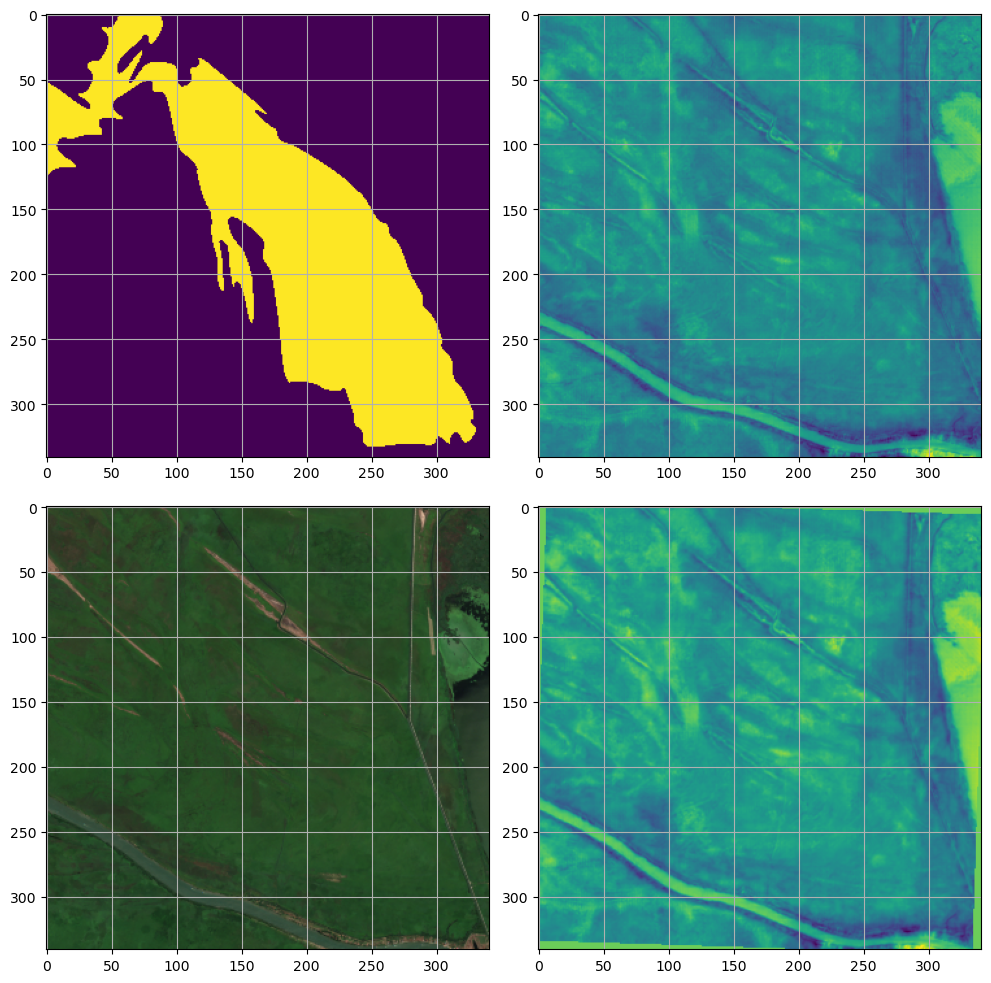

In [96]:
import matplotlib.pyplot as plt
import numpy as np
import os, re
from PIL import Image

f = [f for f in os.listdir('/work/wildfirerisk/europe_dataset/fire_masks/2025/') if f.endswith('npy')][300]
match = re.search(r"lon(-?\d+\.\d+)_lat(-?\d+\.\d+)", f)
lat, lon = float(match.group(2)), float(match.group(1))

plt.figure(figsize=(10,10))

plt.subplot(221)
plt.imshow(np.load(os.path.join('/work/wildfirerisk/europe_dataset/fire_masks/2025/', f)))
plt.grid(True)
plt.subplot(222)
ae = np.load(os.path.join('/work/wildfirerisk/europe_dataset/fire_alphaearth_embeddings_bug/2025', f))
plt.imshow(ae[0].T[::-1])
plt.grid(True)

# ds = download_tile_embeddings(lat, lon, crs='EPSG:5070')
plt.subplot(223)
sat = np.array(Image.open(os.path.join('/work/wildfirerisk/europe_dataset/fire_images/2024', f.replace('.npy','.png'))))
plt.imshow(np.stack([resize(sat[:,:,i]) for i in range(3)], -1))
plt.grid(True)
plt.subplot(224)
plt.imshow(build_and_reproject_tile(lat, lon, {'data':ae}, target_crs="EPSG:3857")['reprojected'][0])
plt.grid(True)

plt.tight_layout()
plt.show()

In [110]:
for f in tqdm(os.listdir('/work/wildfirerisk/small_dataset/alphaearth_embeddings_bug/train/')):
    match = re.search(r"lon(-?\d+\.\d+)_lat(-?\d+\.\d+)", f)
    lat, lon = float(match.group(2)), float(match.group(1))
    ae = np.load(os.path.join('/work/wildfirerisk/small_dataset/alphaearth_embeddings_bug/train/', f))
    ae = np.nan_to_num(ae)
    ae = build_and_reproject_tile(lat, lon, {'data':ae}, target_crs="EPSG:5070")['reprojected']
    np.save(os.path.join('/work/wildfirerisk/small_dataset/alphaearth_embeddings/train/', f), ae)

for f in tqdm(os.listdir('/work/wildfirerisk/large_dataset/alphaearth_embeddings_bug/test/')):
    match = re.search(r"lon(-?\d+\.\d+)_lat(-?\d+\.\d+)", f)
    lat, lon = float(match.group(2)), float(match.group(1))
    ae = np.load(os.path.join('/work/wildfirerisk/large_dataset/alphaearth_embeddings_bug/test/', f))
    ae = np.nan_to_num(ae)
    ae = build_and_reproject_tile(lat, lon, {'data':ae}, target_crs="EPSG:5070")['reprojected']
    np.save(os.path.join('/work/wildfirerisk/large_dataset/alphaearth_embeddings/test/', f), ae)

for year in range(2018,2026):
    for f in tqdm(os.listdir(f'/work/wildfirerisk/europe_dataset/fire_alphaearth_embeddings_bug/{year}/')):
        match = re.search(r"lon(-?\d+\.\d+)_lat(-?\d+\.\d+)", f)
        lat, lon = float(match.group(2)), float(match.group(1))
        ae = np.load(os.path.join(f'/work/wildfirerisk/europe_dataset/fire_alphaearth_embeddings_bug/{year}/', f))
        ae = np.nan_to_num(ae)
        ae = build_and_reproject_tile(lat, lon, {'data':ae}, target_crs="EPSG:3857")['reprojected']
        np.save(os.path.join(f'/work/wildfirerisk/europe_dataset/fire_alphaearth_embeddings/{year}/', f), ae)

for f in tqdm(os.listdir('/work/wildfirerisk/europe_dataset/no_fire_alphaearth_embeddings_bug/')):
    match = re.search(r"lon(-?\d+\.\d+)_lat(-?\d+\.\d+)", f)
    lat, lon = float(match.group(2)), float(match.group(1))
    ae = np.load(os.path.join('/work/wildfirerisk/europe_dataset/no_fire_alphaearth_embeddings_bug/', f))
    ae = np.nan_to_num(ae)
    ae = build_and_reproject_tile(lat, lon, {'data':ae}, target_crs="EPSG:3857")['reprojected']
    np.save(os.path.join('/work/wildfirerisk/europe_dataset/no_fire_alphaearth_embeddings/', f), ae)

100%|██████████| 619/619 [06:13<00:00,  1.66it/s]


sklearn mlp

In [106]:
df = pd.read_json('/work/wildfirerisk/small_dataset/risk_rasters/tile_extrametadata.json')
x, y = [], []
for _, row in df[df['subset']=='train'].iterrows():
    path = '/work/wildfirerisk/small_dataset/alphaearth_embeddings/'+row['tile_file']
    if os.path.exists(path):
        x.append(np.load(path).reshape(64,-1).T)
        y.append(np.load('/work/wildfirerisk/small_dataset/normalised_risk_rasters/'+row['tile_file']).ravel())
x = np.nan_to_num(np.concatenate(x, 0))
y = np.concatenate(y, 0)
section = np.random.choice(np.arange(len(y)), 1000000)

model = LinearRegression().fit(x[section],y[section])
section2 = np.random.choice(np.arange(len(y)), 1000000)
y_true = y[section2]
y_pred = model.predict(x[section2])
print(mean_absolute_error(y_true, y_pred), mean_squared_error(y_true, y_pred))

0.15949660539627075 0.04121841490268707


In [105]:
from sklearn.neural_network import MLPRegressor
model = MLPRegressor(hidden_layer_sizes=(16)).fit(x[section],y[section])
y_true = y[section2]
y_pred = model.predict(x[section2])
print(mean_absolute_error(y_true, y_pred), mean_squared_error(y_true, y_pred))

0.11635636538267136 0.025908472016453743


In [107]:
for f in tqdm(os.listdir('/work/wildfirerisk/large_dataset/alphaearth_embeddings/test/')):
    ae = np.load(os.path.join('/work/wildfirerisk/large_dataset/alphaearth_embeddings/test/', f))
    pred = model.predict(ae.reshape(64,-1).T).reshape(341,341)
    np.save(os.path.join('/work/wildfirerisk/evaluations/alphaearth_mlp/testset/', f), pred)

for year in range(2018,2026):
    for f in tqdm(os.listdir(f'/work/wildfirerisk/europe_dataset/fire_alphaearth_embeddings/{year}/')):
        ae = np.load(os.path.join(f'/work/wildfirerisk/europe_dataset/fire_alphaearth_embeddings/{year}/', f))
        pred = model.predict(ae.reshape(64,-1).T).reshape(341,341)
        np.save(os.path.join(f'/work/wildfirerisk/evaluations/alphaearth_mlp/europe_fires/{year}', f), pred)

for f in tqdm(os.listdir('/work/wildfirerisk/europe_dataset/no_fire_alphaearth_embeddings/')):
    ae = np.load(os.path.join('/work/wildfirerisk/europe_dataset/no_fire_alphaearth_embeddings/', f))
    pred = model.predict(ae.reshape(64,-1).T).reshape(341,341)
    np.save(os.path.join('/work/wildfirerisk/evaluations/alphaearth_mlp/europe_negatives/', f), pred)


100%|██████████| 1968/1968 [01:18<00:00, 25.16it/s]
